# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question:** Can content items in the warehouse be grouped into a few performance archetypes, using only CTR, average position and impressions, that still hold up on clients the model never saw — and can each archetype be mapped to a sensible review action?

**Decision it supports:** Where should an editorial / SEO team spend limited review hours next quarter: fix titles, look closer at a page, or leave it alone?

**Who acts:** Content operations leads (assign the work) and SEO strategists (do the title / meta / linking work).

#### Cost of a wrong call.

- Prune a page that was really earning traffic → traffic lost overnight.
- Rewrite a whole article when a title tweak was enough → expensive hours wasted.

In [ ]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
warnings.filterwarnings('ignore')

SEED = 42
SIL_N = 20000
np.random.seed(SEED)
os.makedirs('work/outputs/figures', exist_ok=True)

def find(name):
    for d in ['work/outputs', '/content/drive/MyDrive', '.']:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{name} not found - run w07 first or upload it next to this notebook.")

ACTION_MAP = {
    'High-Reach Opportunity':  ('FIX_TITLE_META_PRIORITIZED',  'RC_HIGH_REACH_CONFIRMED_GAP'),
    'Low-Visibility / Buried': ('REVIEW_FOR_PRUNE_OR_REWORK',  'RC_WORST_POSITION_LOW_SIGNAL'),
    'Steady / Low Signal':     ('LOW_PRIORITY_REVIEW',         'RC_MODEST_ALL_AXES'),
    'Already Converting':      ('MONITOR_ONLY',                'RC_HIGH_CTR_NO_GAP'),
}
for a, (act, rc) in ACTION_MAP.items():
    print(f"{a:26s} -> {act:28s} ({rc})")

High-Reach Opportunity     -> FIX_TITLE_META_PRIORITIZED   (RC_HIGH_REACH_CONFIRMED_GAP)
Low-Visibility / Buried    -> REVIEW_FOR_PRUNE_OR_REWORK   (RC_WORST_POSITION_LOW_SIGNAL)
Steady / Low Signal        -> LOW_PRIORITY_REVIEW          (RC_MODEST_ALL_AXES)
Already Converting         -> MONITOR_ONLY                 (RC_HIGH_CTR_NO_GAP)


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank internship warehouse, build v20260703 (pseudonymized, gated).

**Table used:** fact_content_daily_performance only — Search Console columns: impressions, clicks, average position.

**Window:** Report dates 2025-01-27 to 2026-06-30. Each item is summed over its own available history (history depth differs by client) — not a Jan–Jun 2026 window.

One row = one content item (content_hash_id), one aggregate over its history.

**Kept:** Daily rows with impressions > 0, then items with at least 100 impressions in total → 182,135 items from 59 clients (the release lists 104 clients; the rest have too little search history to pass the filter).

**Excluded:**
- GA4 columns — zero-filled before each client's GA4 start; not needed for CTR / position / volume.
- fact_content_query_90d — its 90-day window overlaps the most recent months; skipping it avoids window-overlap leakage.
- dim_content / dim_clients — no field from them is a feature.
- Items under 100 impressions — CTR ratios are too noisy to act on (w04).

**Unit note:** In the warehouse aggregate, CTR is a fraction (0.0023 = 0.23%) — do not mix it with the ×100-percentage starter CSV.

**IDs (content_hash_id, client_hash_id) are pseudonyms:** grouping and splitting only, never features.

In [ ]:
# Load the w07 queue + summary, then confirm row count, grain, and missingness

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(find('w07_action_playbook_queue.csv'))
summary = json.load(open(find('w07_playbook_summary.json')))

print(f"Rows: {len(df):,}   Clients: {df['client_hash_id'].nunique()}")
print(f"Impressions per item: min {df['impressions'].min():.0f}, median {df['impressions'].median():.0f}, max {df['impressions'].max():,.0f}")

dups = df['content_hash_id'].duplicated().sum()
print(f"Duplicate content_hash_id rows: {dups}")
print(f"Missing values in ctr / avg_position / impressions: "
      f"{int(df[['ctr','avg_position','impressions']].isna().sum().sum())}")
print(f"Items with avg_position == 0: {(df['avg_position'] == 0).sum()}")

assert len(df) == summary['n_items'] == 182135
assert df['client_hash_id'].nunique() == 59
assert dups == 0 and df['impressions'].min() >= 100

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 182,135   Clients: 59
Impressions per item: min 100, median 1513, max 2,902,616
Duplicate content_hash_id rows: 0
Missing values in ctr / avg_position / impressions: 0
Items with avg_position == 0: 1


In [ ]:
# verify the release's own row count / date range / client count straight from HF

try:
    from google.colab import userdata
    import duckdb
    con = duckdb.connect()
    con.execute("CREATE SECRET (TYPE huggingface, TOKEN ?)", [userdata.get('HF_TOKEN')])
    base = 'hf://datasets/FlyRank/internship-warehouse'
    print(con.sql(f"""SELECT COUNT(*) AS rows, MIN(report_date) AS first_day, MAX(report_date) AS last_day
                      FROM read_parquet('{base}/fact_content_daily_performance/**/*.parquet')""").df())
    print(con.sql(f"SELECT COUNT(*) AS clients FROM read_parquet('{base}/dim_clients.parquet')").df())
except Exception as e:
    print("Warehouse check skipped (no Colab secret / no access):", type(e).__name__)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

       rows  first_day   last_day
0  78835655 2025-01-27 2026-06-30
   clients
0      104


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**
- CTR, position and volume together describe how a page behaves in search — not what it says.
- Clients differ, so a model must be tested on clients it did not train on.

**Features (3):** ctr, avg_position, impressions_log = log10(impressions + 1). No missing values, so no fills. Standardized on training clients only.

**Label:** None — unsupervised. The baseline score is a comparison ranking, never an input.

**Baseline (w04):**
score = (expected_ctr − actual_ctr) × impressions,
clipped at zero. expected_ctr is the average CTR of items in the same position quartile.

**Model:** K-Means, random_state=42, n_init=10. k compared from 3 to 9.

**Validation design:** 80/20 split grouped by client: 47 train, 12 test.

**Leakage checks:**
- (1) no baseline-derived column is a feature,
- (2) shared-input check,
- (3) window check.

In [ ]:
# Build the 3 model features and split clients 80/20 (grouped, never row-random)

df = df.sort_values('score', ascending=False, kind='stable').reset_index(drop=True)
df['impressions_log'] = np.log10(df['impressions'] + 1)
FEATURES = ['ctr', 'avg_position', 'impressions_log']
X = df[FEATURES].values

clients = df['client_hash_id'].unique()
shuffled = np.random.RandomState(SEED).permutation(clients)
train_clients = set(shuffled[:int(0.8 * len(shuffled))])
train_mask = df['client_hash_id'].isin(train_clients).values
test_mask = ~train_mask

print(f"Train: {len(train_clients)} clients, {train_mask.sum():,} items")
print(f"Test:  {len(clients) - len(train_clients)} clients, {test_mask.sum():,} items")

assert not (set(df.loc[train_mask, 'client_hash_id']) & set(df.loc[test_mask, 'client_hash_id']))
assert train_mask.sum() == 161153 and test_mask.sum() == 20982

scaler = StandardScaler().fit(X[train_mask])
Xs_train, Xs_test = scaler.transform(X[train_mask]), scaler.transform(X[test_mask])

Train: 47 clients, 161,153 items
Test:  12 clients, 20,982 items


In [ ]:
# Compare k=3..9 on held-out clients and pick the simplest k near the best score

LOCKED_K = {3: (0.356, 0.269), 4: (0.378, 0.336), 5: (0.379, 0.336), 6: (0.315, 0.267),
            7: (0.316, 0.267), 8: (0.310, 0.264), 9: (0.313, 0.275)}
rows = []
for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300).fit(Xs_train)
    tr = silhouette_score(Xs_train, km.labels_, sample_size=SIL_N, random_state=SEED)
    te = silhouette_score(Xs_test, km.predict(Xs_test), sample_size=SIL_N, random_state=SEED)
    rows.append((k, tr, te, *LOCKED_K[k]))
ksel = pd.DataFrame(rows, columns=['k', 'train_sil', 'test_sil', 'locked_train', 'locked_test'])
print(ksel.round(3).to_string(index=False))

best = ksel['test_sil'].max()
K = int(ksel.loc[ksel['test_sil'] >= best - 0.005, 'k'].min())
print(f"\nBest held-out silhouette: {best:.3f}. Simplest k within 0.005: k = {K}")
assert K == 4
assert (ksel['test_sil'] - ksel['locked_test']).abs().max() < 0.02

 k  train_sil  test_sil  locked_train  locked_test
 3      0.355     0.268         0.356        0.269
 4      0.377     0.336         0.378        0.336
 5      0.377     0.335         0.379        0.336
 6      0.315     0.267         0.315        0.267
 7      0.315     0.267         0.316        0.267
 8      0.309     0.263         0.310        0.264
 9      0.312     0.275         0.313        0.275

Best held-out silhouette: 0.336. Simplest k within 0.005: k = 4


In [ ]:
# Fit K-Means on all items, name clusters by relative rank, and check the naming didn't collide

scaler_all = StandardScaler().fit(X)
km_all = KMeans(n_clusters=K, random_state=SEED, n_init=10, max_iter=300).fit(scaler_all.transform(X))
df['cluster'] = km_all.labels_

prof = df.groupby('cluster').agg(n=('score', 'size'), mean_ctr=('ctr', 'mean'),
                                 mean_position=('avg_position', 'mean'),
                                 mean_impressions=('impressions', 'mean'),
                                 mean_score=('score', 'mean')).reset_index()
prof['ctr_rank'] = prof['mean_ctr'].rank(ascending=False)
prof['position_rank'] = prof['mean_position'].rank(ascending=True)
prof['impressions_rank'] = prof['mean_impressions'].rank(ascending=False)
prof['score_rank'] = prof['mean_score'].rank(ascending=False)

def name_archetype(r):
    if r['ctr_rank'] == 1 and r['score_rank'] == prof['score_rank'].max(): return 'Already Converting'
    if r['impressions_rank'] == 1 and r['score_rank'] == 1:                return 'High-Reach Opportunity'
    if r['position_rank'] == prof['position_rank'].max():                  return 'Low-Visibility / Buried'
    return 'Steady / Low Signal'

prof['archetype'] = prof.apply(name_archetype, axis=1)
assert prof['archetype'].nunique() == len(prof)
df['archetype_refit'] = df['cluster'].map(dict(zip(prof['cluster'], prof['archetype'])))

agree = (df['archetype_refit'] == df['archetype']).mean()
print(prof[['cluster', 'archetype', 'n', 'mean_ctr', 'mean_position', 'mean_impressions', 'mean_score']].round(4).to_string(index=False))
print(f"\nRefit vs saved w07 archetypes: {100 * agree:.2f}% agree")
assert agree > 0.99

 cluster               archetype     n  mean_ctr  mean_position  mean_impressions  mean_score
       0     Steady / Low Signal 77858    0.0024        13.7327          807.0961      1.2802
       1 Low-Visibility / Buried 29215    0.0009        45.7844         1458.3467      1.6070
       2  High-Reach Opportunity 67736    0.0032        11.7661        24073.9146     32.9690
       3      Already Converting  7326    0.0209        10.2509         3355.3490      0.0000

Refit vs saved w07 archetypes: 99.98% agree


In [ ]:
# Leakage hunt: no banned column as a feature, shared-input correlation, window sanity check

BANNED = ['score', 'ctr_gap', 'expected_ctr', 'action_label', 'reason_code', 'position_bucket',
          'playbook_action', 'playbook_reason_code', 'priority_rank', 'archetype', 'archetype_refit', 'cluster']
assert not set(FEATURES) & set(BANNED)
print("Features:", FEATURES)
print("No banned column is a feature: OK\n")

print("corr(score, feature):")
for col in ['ctr', 'avg_position', 'impressions', 'impressions_log']:
    r, _ = pearsonr(df[col], df['score'])
    print(f"  {col:16s} {r:+.3f}")
r_imp, _ = pearsonr(df['impressions'], df['score'])
assert abs(r_imp - 0.70) < 0.05

print("\nWindow check: all three features are totals over the same history - no future window, no label window.")

Features: ['ctr', 'avg_position', 'impressions_log']
No banned column is a feature: OK

corr(score, feature):
  ctr              -0.064
  avg_position     -0.123
  impressions      +0.703
  impressions_log  +0.391

Window check: all three features are totals over the same history - no future window, no label window.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

There is no accuracy to compare in an unsupervised lane. Two honest questions instead:

- Do the clusters hold up on unseen clients? Naive split vs grouped split, next to a random-label base rate.

- What do the clusters add on top of the w04 baseline? Same 182,135 items, same score.

In [ ]:
# Naive random split vs grouped-by-client split, plus a random-label base rate

def split_sil(mtr, mte):
    sc = StandardScaler().fit(X[mtr]); a, b = sc.transform(X[mtr]), sc.transform(X[mte])
    km = KMeans(n_clusters=K, random_state=SEED, n_init=10, max_iter=300).fit(a)
    return (silhouette_score(a, km.labels_, sample_size=SIL_N, random_state=SEED),
            silhouette_score(b, km.predict(b), sample_size=SIL_N, random_state=SEED))

np.random.seed(SEED)
idx = np.random.permutation(len(df)); cut = int(0.8 * len(df))
naive_train = np.zeros(len(df), bool); naive_train[idx[:cut]] = True
naive_tr, naive_te = split_sil(naive_train, ~naive_train)
grp_tr, grp_te = split_sil(train_mask, test_mask)

both = set(df.loc[naive_train, 'client_hash_id']) & set(df.loc[~naive_train, 'client_hash_id'])
rand_labels = np.random.RandomState(SEED).randint(0, K, size=len(Xs_test))
rand_sil = silhouette_score(Xs_test, rand_labels, sample_size=SIL_N, random_state=SEED)

LOCKED_SPLIT = {'naive': (0.371, 0.375), 'grouped': (0.373, 0.335)}
split_table = pd.DataFrame({
    'split': ['Naive random rows', 'Grouped by client', 'Random labels (base rate)'],
    'train_sil_live': [naive_tr, grp_tr, np.nan],
    'test_sil_live': [naive_te, grp_te, rand_sil],
    'train_sil_locked_w06': [0.371, 0.373, np.nan],
    'test_sil_locked_w06': [0.375, 0.335, np.nan],
})
print(split_table.round(3).to_string(index=False))
print(f"\nClients on BOTH sides of naive split: {len(both)} of {df['client_hash_id'].nunique()} (locked w06: 55)")
assert abs(grp_te - 0.335) < 0.02 and abs(naive_te - 0.375) < 0.02

                    split  train_sil_live  test_sil_live  train_sil_locked_w06  test_sil_locked_w06
        Naive random rows           0.367          0.373                 0.371                0.375
        Grouped by client           0.377          0.336                 0.373                0.335
Random labels (base rate)             NaN         -0.007                   NaN                  NaN

Clients on BOTH sides of naive split: 54 of 59 (locked w06: 55)


In [ ]:
# Compare archetypes against the baseline score: profile table, ANOVA effect size, action crosstab

by_arch = df.groupby('archetype').agg(n=('score', 'size'), mean_ctr=('ctr', 'mean'),
                                      mean_position=('avg_position', 'mean'),
                                      mean_impressions=('impressions', 'mean'),
                                      mean_score=('score', 'mean'),
                                      median_score=('score', 'median')).round(4)
print(by_arch.sort_values('mean_score', ascending=False).to_string())

groups = [g['score'].values for _, g in df.groupby('archetype')]
F, p = f_oneway(*groups)
grand = df['score'].mean()
eta2 = sum(len(g) * (g.mean() - grand) ** 2 for g in groups) / ((df['score'] - grand) ** 2).sum()
print(f"\nANOVA on score by archetype: F = {F:,.0f}, p < 1e-300, eta-squared = {eta2:.3f}")
print("Read: clusters and score share inputs - a consistency check, not proof of new signal.")

print("\nBaseline tiers alone:")
print(df['action_label'].value_counts().to_string())
print("\nPlaybook actions (archetype-based):")
print(df['playbook_action'].value_counts().to_string())
print("\nWhere the baseline's HIGH_PRIORITY items land:")
print(pd.crosstab(df['archetype'], df['action_label']).to_string())

                             n  mean_ctr  mean_position  mean_impressions  mean_score  median_score
archetype                                                                                          
High-Reach Opportunity   67701    0.0032        11.7636        24084.8460     32.9837        8.5338
Low-Visibility / Buried  29210    0.0009        45.7875         1458.5729      1.6074        0.5304
Steady / Low Signal      77898    0.0024        13.7349          808.0066      1.2816        0.6268
Already Converting        7326    0.0209        10.2509         3355.3490      0.0000        0.0000

ANOVA on score by archetype: F = 4,258, p < 1e-300, eta-squared = 0.066
Read: clusters and score share inputs - a consistency check, not proof of new signal.

Baseline tiers alone:
action_label
NO_ACTION_CTR_ON_TRACK          160982
FIX_TITLE_META_MONITOR           15882
FIX_TITLE_META_HIGH_PRIORITY      5271

Playbook actions (archetype-based):
playbook_action
LOW_PRIORITY_REVIEW           77898

The naive split looks better on held-out rows only because 54/59 clients sit on both sides. On truly unseen clients: silhouette 0.335 vs 0.373 on train — a small, real gap. Clusters explain only ~6.6% of the score's variance (eta²) and score correlates +0.70 with impressions — the archetypes group what the baseline already ranks; they don't out-rank it. The value-add is different actions, not a better ranking.

## 5. Limitations

*What this work cannot claim.*

**Cannot claim**

- Meaning or quality. Only CTR, position, volume — no topic, no quality.
- Cause or gain. One snapshot, no experiment. Score is clicks below the position-bucket average, not clicks a fix would win.
- New discovery from the ANOVA. Score and clusters share the same three raw inputs.
- Stable labels. Names are relative ranks across 4 clusters; a refit can rename them.

**Design caveats**

- k = 4 and k = 5 tie on held-out silhouette (0.336) — chose k=4 for simplicity.
- Border items: 2,149 items (1.2%) have negative silhouette; none scores ≥ 100; largest scores 59.6.
- Only 12 clients held out; a few clients dominate volume.
- Baseline's expected CTR mixes windows (daily averages vs March-2026 position cut-offs) — treat as a rough yardstick.
- ~27% of items have zero clicks, pulling "Low-Visibility" CTR toward zero.
- No trend signal: an "Already Converting" page today can decline tomorrow.

In [ ]:
# Put a real number next to each limitation named in the markdown above

hro = df[df['archetype'] == 'High-Reach Opportunity']
hp = df[df['action_label'] == 'FIX_TITLE_META_HIGH_PRIORITY']
limits = {
    'items_with_zero_clicks_pct': 100 * (df['ctr'] == 0).mean(),
    'items_with_avg_position_0': int((df['avg_position'] == 0).sum()),
    'largest_client_share_of_items_pct': 100 * df['client_hash_id'].value_counts(normalize=True).iloc[0],
    'top3_clients_share_of_high_reach_pct': 100 * hro['client_hash_id'].value_counts(normalize=True).head(3).sum(),
    'high_priority_items': int(len(hp)),
    'high_priority_share_of_total_score_pct': 100 * hp['score'].sum() / df['score'].sum(),
    'test_clients': int(len(clients) - len(train_clients)),
    'boundary_items_negative_silhouette_w07': int(summary['n_boundary_items']),
    'boundary_items_pct': 100 * summary['n_boundary_items'] / len(df),
    'corr_score_impressions': float(r_imp),
}
for k_, v in limits.items():
    print(f"{k_:42s} {v:,.3f}" if isinstance(v, float) else f"{k_:42s} {v:,}")

items_with_zero_clicks_pct                 27.100
items_with_avg_position_0                  1
largest_client_share_of_items_pct          16.205
top3_clients_share_of_high_reach_pct       53.462
high_priority_items                        5,271
high_priority_share_of_total_score_pct     54.555
test_clients                               12
boundary_items_negative_silhouette_w07     2,149
boundary_items_pct                         1.180
corr_score_impressions                     0.703


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Order:** Rank 1 by size of estimated shortfall; ranks 2–4 by cost of a wrong call. Inside each archetype, items ranked by baseline score.

**Human review first:** Anything that changes or removes live content needs a person's approval — never auto-delete or auto-rewrite from a cluster label.

In [ ]:
# Rank the 4 archetypes, show what share of items/impressions/shortfall each holds, and preview rank-1

ORDER = ['High-Reach Opportunity', 'Low-Visibility / Buried', 'Steady / Low Signal', 'Already Converting']
rec = df.groupby('archetype').agg(items=('score', 'size'), impressions=('impressions', 'sum'),
                                  shortfall=('score', 'sum')).loc[ORDER]
rec['pct_items'] = 100 * rec['items'] / rec['items'].sum()
rec['pct_impressions'] = 100 * rec['impressions'] / rec['impressions'].sum()
rec['pct_shortfall'] = 100 * rec['shortfall'] / rec['shortfall'].sum()
rec['action'] = [ACTION_MAP[a][0] for a in rec.index]
rec['reason_code'] = [ACTION_MAP[a][1] for a in rec.index]
rec.insert(0, 'rank', range(1, len(rec) + 1))
print(rec[['rank', 'action', 'reason_code', 'items', 'pct_items', 'pct_impressions', 'pct_shortfall']].round(1).to_string())

top10 = (hro.sort_values('score', ascending=False).head(10)
            .assign(rank_in_queue=lambda d: range(1, len(d) + 1), ctr_pct=lambda d: 100 * d['ctr'])
            [['rank_in_queue', 'score', 'ctr_pct', 'avg_position', 'impressions']])
print("\nTop 10 of rank-1 queue:")
print(top10.round(2).to_string(index=False))

n_first = (hro['score'] >= 100).sum()
print(f"\nRank-1 items with score >= 100 (start here): {n_first:,}")

                         rank                      action                   reason_code  items  pct_items  pct_impressions  pct_shortfall
archetype                                                                                                                                
High-Reach Opportunity      1  FIX_TITLE_META_PRIORITIZED   RC_HIGH_REACH_CONFIRMED_GAP  67701       37.2             92.6           93.8
Low-Visibility / Buried     2  REVIEW_FOR_PRUNE_OR_REWORK  RC_WORST_POSITION_LOW_SIGNAL  29210       16.0              2.4            2.0
Steady / Low Signal         3         LOW_PRIORITY_REVIEW            RC_MODEST_ALL_AXES  77898       42.8              3.6            4.2
Already Converting          4                MONITOR_ONLY            RC_HIGH_CTR_NO_GAP   7326        4.0              1.4            0.0

Top 10 of rank-1 queue:
 rank_in_queue   score  ctr_pct  avg_position  impressions
             1 4176.07     0.13          3.98    1055962.0
             2 3986.79     0.

- High-Reach Opportunity → fix title/meta first. Start with items scoring ≥ 100.
- Low-Visibility / Buried → review for prune or rework, human only.
- Steady / Low Signal → low-priority review.
- Already Converting → monitor only.

**Gates:** every prune/rework item; the 2,149 negative-silhouette items; large single-client actions; any refit where two clusters collide. Do not act below the 100-impression cut-off.

**Stale when:** held-out silhouette falls well below 0.335; naming check fails; corr(score, impressions) drifts far from +0.70; or 90+ days pass unchecked.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

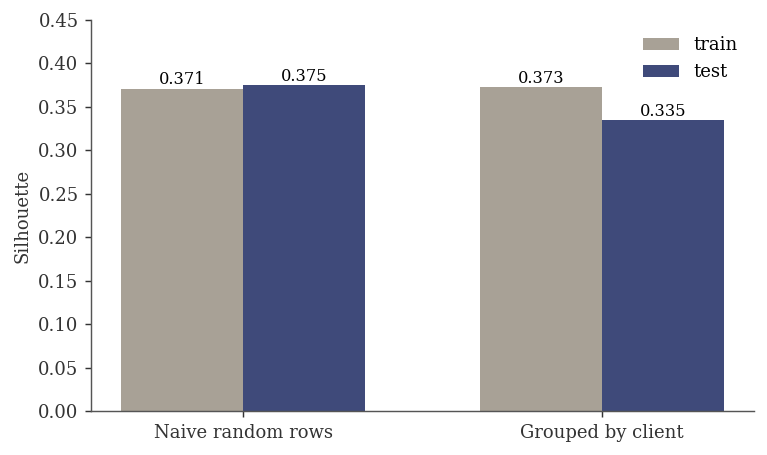

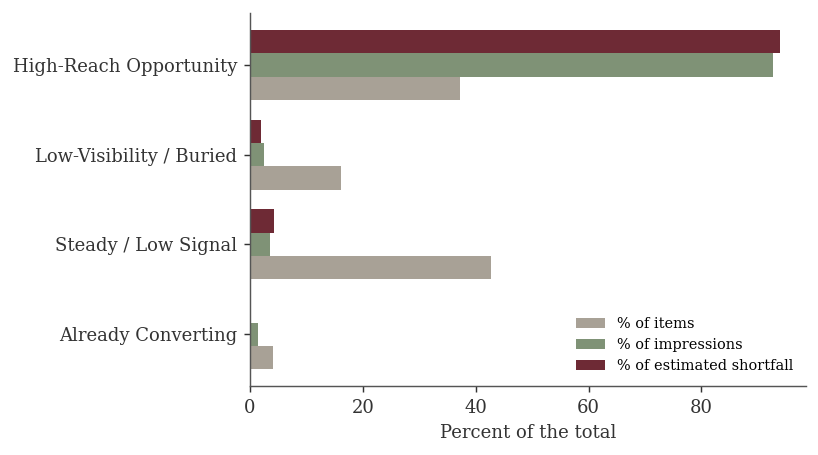

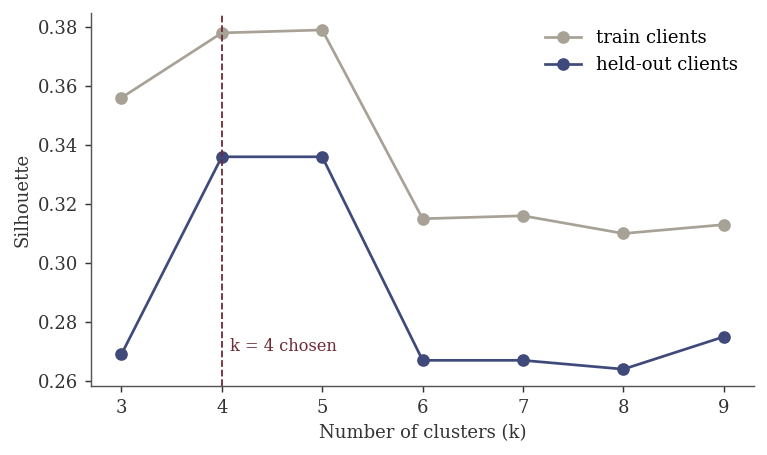

In [ ]:
# Fig 1: silhouette on train vs test, naive split vs grouped split (locked w06 numbers)

INDIGO, OXBLOOD, SAGE, GREY = '#3F4A7A', '#6E2A35', '#7F9276', '#A8A196'
plt.rcParams.update({'font.family': 'serif', 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#555', 'axes.labelcolor': '#333', 'xtick.color': '#333',
                     'ytick.color': '#333', 'figure.dpi': 130})

fig, ax = plt.subplots(figsize=(6, 3.6))
x = np.arange(2); w = 0.34
tr_vals = [LOCKED_SPLIT['naive'][0], LOCKED_SPLIT['grouped'][0]]
te_vals = [LOCKED_SPLIT['naive'][1], LOCKED_SPLIT['grouped'][1]]
ax.bar(x - w/2, tr_vals, w, color=GREY, label='train'); ax.bar(x + w/2, te_vals, w, color=INDIGO, label='test')
for xi, v in zip(x - w/2, tr_vals): ax.text(xi, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)
for xi, v in zip(x + w/2, te_vals): ax.text(xi, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['Naive random rows', 'Grouped by client'])
ax.set_ylabel('Silhouette'); ax.set_ylim(0, 0.45); ax.legend(frameon=False, loc='upper right')
fig.tight_layout(); fig.savefig('work/outputs/figures/fig1_split_honesty.png'); plt.show()



# Fig 2: where items / impressions / estimated shortfall sit across the 4 archetypes

fig, ax = plt.subplots(figsize=(6.4, 3.6))
labs = ORDER[::-1]; yy = np.arange(len(labs)); h = 0.26
for off, col, name in [(-h, GREY, '% of items'), (0, SAGE, '% of impressions'), (h, OXBLOOD, '% of estimated shortfall')]:
    key = {'% of items': 'pct_items', '% of impressions': 'pct_impressions', '% of estimated shortfall': 'pct_shortfall'}[name]
    ax.barh(yy + off, rec.loc[labs, key], h, color=col, label=name)
ax.set_yticks(yy); ax.set_yticklabels(labs); ax.set_xlabel('Percent of the total')
ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout(); fig.savefig('work/outputs/figures/fig2_where_shortfall_sits.png'); plt.show()



# Fig 3: held-out silhouette across k=3..9, marking the chosen k=4

ks = list(LOCKED_K)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(ks, [LOCKED_K[k][0] for k in ks], color=GREY, marker='o', label='train clients')
ax.plot(ks, [LOCKED_K[k][1] for k in ks], color=INDIGO, marker='o', label='held-out clients')
ax.axvline(4, color=OXBLOOD, lw=1, ls='--'); ax.text(4.08, 0.27, 'k = 4 chosen', color=OXBLOOD, fontsize=9)
ax.set_xlabel('Number of clusters (k)'); ax.set_ylabel('Silhouette'); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig('work/outputs/figures/fig3_k_selection.png'); plt.show()

**Fig 1:** On unseen clients silhouette falls to 0.335 from 0.373 on train; the naive split hides this because 54/59 clients appear on both sides (55/59 in the original w06 run — the exact count is sensitive to row order, see Section 4).

**Fig 2:** High-Reach Opportunity holds ~37% of items but ~94% of the estimated click shortfall.

**Fig 3:** Held-out silhouette peaks at k=4 and k=5 (tied, 0.336); k=4 kept as simpler.

In [ ]:
# Write every number/table the paper quotes to one public-safe JSON file

paper_tables = {
    'n_items': int(len(df)), 'n_clients': int(df['client_hash_id'].nunique()),
    'k_selection_locked_w05': {str(k): {'train_sil': v[0], 'test_sil': v[1]} for k, v in LOCKED_K.items()},
    'split_locked_w06': {'naive': {'train': 0.371, 'test': 0.375, 'clients_on_both_sides': 55},
                         'grouped': {'train': 0.373, 'test': 0.335}},
    'split_live_recheck': {'naive_test': float(naive_te), 'grouped_test': float(grp_te), 'random_label_test': float(rand_sil)},
    'anova': {'F': float(F), 'eta_squared': float(eta2)},
    'archetypes': by_arch.reset_index().to_dict(orient='records'),
    'recommendations': rec.reset_index().to_dict(orient='records'),
    'limits': limits,
}
with open('work/outputs/capstone_paper_tables.json', 'w') as f:
    json.dump(paper_tables, f, indent=2, default=str)
print("Wrote work/outputs/capstone_paper_tables.json and 3 figures in work/outputs/figures/")

Wrote work/outputs/capstone_paper_tables.json and 3 figures in work/outputs/figures/


## 8. Demo outline

**1. Question**
- A content team has thousands of pages and limited hours.
- Which pages should a person look at first?

**2. Method**
- Data: Search Console performance for 182,135 pages across 59 clients (FlyRank warehouse, pseudonymized).
- Baseline: score = (expected CTR − actual CTR) × impressions, which ranks pages by estimated click shortfall.
- Model: K-Means (k=4) on CTR, average position and log impressions.
- Test: split by client, so the model is scored on 12 clients it never saw.

**3. One chart**
- Show fig1: silhouette for a naive split vs a split grouped by client.
- Say it like this: "A random split puts the same client on both sides, so 55 of 59 clients were in both train and test. It is like testing a recipe in the kitchen where you wrote it. A grouped split tests it in a new kitchen."

**4. One honest result**
- On unseen clients the silhouette is 0.335, not the naive 0.375.
- One archetype, High-Reach Opportunity, holds 37% of pages but about 94% of the estimated shortfall.
- Limit: the score correlates +0.70 with impressions, and the clusters use impressions too. So their agreement is partly built in.

**5. One recommendation**
- Start human review with High-Reach Opportunity pages: fix title and meta, highest scores first.
- A person approves anything that changes or removes live content. Never auto-delete.
- This is decision-support. It does not show that acting on the queue improves clicks.

## 9. Shareable cuts

#### Social post (methodology)
The most useful thing I learned in my ML internship wasn't a model. It was a validation mistake.

I clustered 182,135 pages of pseudonymized search data into 4 content archetypes. My first test score looked good: silhouette 0.375.

Then I split by client, so the model was tested on clients it had never seen. The score dropped to 0.335. Under my first split, 55 of 59 clients appeared in both train and test, so the model had already seen the groups it was being graded on.

Lesson: split by the thing you want your model to generalize to, and report the lower number.

Write-up with the full method and limits: https://dennis-jt-717.github.io/FR-PRJ/

#### Employer summary (3 sentences)
I built a clustering and ranking pipeline that groups web pages into four search-behavior archetypes and orders them for human review, using Search Console data for 182,135 pages across 59 pseudonymized client sites. It showed that a naive split overstated cluster quality (silhouette 0.375 vs 0.335 on unseen clients) and that my score tracks impression volume (correlation +0.70). I published the method, limits and a ranked review playbook as a research paper, framed as decision-support for content teams.

## Self-check

Before you submit, confirm each line honestly:

- [✔] Every section above is filled — markdown thinking AND the code that backs it
- [✔] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✔] No client names, URLs, or private queries anywhere
- [✔] My claims use careful words: observed, measured, directional, decision-support
- [✔] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.